# This notebook documents the UQ of Mingrone, 2017 $^{238}$U(n,$\gamma$) experimental data as part of data preparation for GMA (Data release: LA-UR-25-32229)

## Here the necessary classes and functions are loaded

In [8]:
import os
from importlib import reload
import matplotlib.pyplot as plt
%matplotlib inline 
from numpy import array, shape, ones, zeros, loadtxt, arange, sqrt

In [10]:
homedir = os.getcwd() +'/'

In [12]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [16]:
import Class_ngammacs as Cg
reload(Cg)

<module 'Class_ngammacs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_ngammacs.py'>

## Plotting of data

In [18]:
datafile = '../Data/U-238/n-092-U-238_ngcs_ENDFBVIII1.txt'
alldata  = loadtxt(datafile)
EVIII1   = alldata[:,0] # MeV
csVIII1  = alldata[:,1] # b

In [22]:
datafile = homedir+'DS6013_Mingrone_truncated.txt'
alldata  = loadtxt(datafile)

Einc  = (alldata[:,0]*0.5 + alldata[:,1]*0.5)*1.0e-3 # MeV
Einclow  = alldata[:,0]*1.0e-3 # MeV
Einchigh = alldata[:,1]*1.0e-3 # MeV
Ersl = 2.0*ones(shape(Einc)[0],dtype=float) #%
edgesE      = zeros(len(Einc) + 1)
edgesE[:-1] = Einclow
edgesE[-1]  = Einchigh[-1]

Data  = alldata[:,2]*1.0e-3 

Statunc = alldata[:,3]*100.0/alldata[:,2]
NeutronFluxUnc = alldata[:,4]
BackgroundUnc = alldata[:,5]

Correction_selfshielding_multiplescattering = alldata[:,6]

samplemass_unc = 0.1 # %
normalizationunc = 1.0 # %

Totunc = sqrt(Statunc*Statunc+NeutronFluxUnc*NeutronFluxUnc+BackgroundUnc*BackgroundUnc)

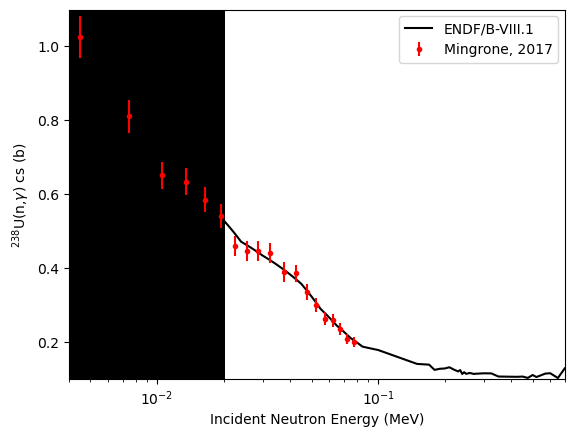

In [24]:
plt.figure(1)
plt.xlim([0.004,0.7])
plt.ylim([0.1,1.1])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel(r'$^{238}$U(n,$\gamma$) cs (b)')
plt.semilogx(EVIII1,csVIII1,'k',zorder=1,label="ENDF/B-VIII.1")
plt.errorbar(Einc,Data,Totunc*Data/100.0,fmt='r.',label="Mingrone, 2017",zorder=2)
plt.legend()
#plt.savefig('/Users/dneudecker/Documents/pu-239-neutron-induced-fission-cross-section/ARIADNE/WorkDir/Ti-48/cs_PlotEXFOR/Ti48_totcs.pdf')

## Comments:
- 23234004 and 23234005 are from the same raw data, but 23234004 is given with broader energy bins. I take 23234004 as the Standards use averaged data.
- A well-documented data set. I have two areas of concern: The one area of concern is that the neutron flux is evaluated using several reactions as we have previously seen for n_TOF measurements. My second area of concern is the fact that a strong deviation from VIII.1 can be seen from 80 keV to 400 keV. They agree with Ullman data but disageree with Carlson 2009 data. No justification is given in the paper.
- In EXFOR, it is written: "Flux was monitored during measurement by a silicon based neutron beam monitor (SiMoN) relying on 6Li(n,t) reaction." However, the data are only given as 238U(n,g) cs in EXFOR not in ratio to 6Li(n,t) cs. For the Standards, it would be better to have the 238U(n,g)/6Li(n,t) ratios. I wonder if we could get them? ... Reading the journal article, this is the typical n_TOF evaluated neutron flux. There is little hope in getting ratio data. So, I will move forward without it.
- The method used is the "total energy detection technique".
- The sample mass uncertainty of 0.1% is on the low end but realistic for a metal sample.
- There is no impurity uncertainty given but the sample has extremely high purity. Therefore, I set this to 0.
- All uncertainties expected by the templates of expected measurement uncertainties are provided.
- All important effects were corrected as far as I can see.

In [26]:
features = {
  "Author": ["F.Mingrone", "C.Massimi", "G.Vannini", "N.Colonna", "F.Gunsing", "and n_TOF Collaboration (100+ authors)"],
  "Year": "2017",
  "Absolute": "y",# check 
  "GMAnumber": "6013",
  "MonitorReaction": "(3-LI-6(N,T)2-HE-4,,SIG)",
  "EXFORnumber": ["23234004"],
  "CorrelatedData": ["23234005"],
  "Facility": ["SYNCH", "2ZZZCER"],
  "Institute": ["2ZZZCER", "2ITYUBO", "2ITYBAU", "2FR SAC", "3CROZAG", "and 40+ other institutes"],
  "Isotope": "U-238",
  "quantity": "cs",
  "reaction": "n,gamma",
  "MeasurementType": "TED",
  "ConcernEXFOR": "None",
  "AcceptedVsRejected": "accepted",
  "BackgroundCorrected": "y",
  "AlphaBackground": "N/A",
  "CosmicRaysBackground": "N/A",
  "GammaBackground": "y",
  "RandomCoincidenceBackground": "y",
  "ShadowBarBackground": "N/A",
  "WrapAroundBackground": "y",
  "SampleGammaRaySelfabsorption": "N/A",
  "SampleFoilGeometryCorrection": "N/A",
  "SampleNeutronFluxCorrection": "y",
  "SampleNeutronFluxContaminationCorrection": "unknown",
  "MonitorGammaRaySelfabsorption": "N/A",
  "MonitorFoilGeometryCorrection": "N/A",
  "MonitorNeutronFluxCorrection": "N/A",
  "MonitorFluxContaminationCorrection": "N/A",
  "NeutronMultipleScatteringSampleBackingCorrected": "y",
  "NeutronMultipleScatteringSurroundingCorrected": "y",
  "NeutronAttenuationSampleBackingCorrected": "y",
  "NeutronAttenuationSurroundingCorrected": "y",
  "EfficiencyCorrected": "y",
  "StoppingPowerCorrected": "N/A",
  "SampleRoughnessCorrected": "unknown",
  "SampleDecayCorrected": "y",
  "FissionFragmentAbsorptioninSampleCorrected": "N/A",
  "SignalPulsePileupCorrected": "y",
  "DeadtimeCorrected": "y",
  "AngularDistributionFissionFragmentsCorrected": "N/A",
  "ImpuritiesCorrected": "y",
  "SelfShieldingCorrected": "y",
  "ForwardBoostCorrected": "N/A",
  "MissingCorrections": ["none"],
  
  "CaptureDetector": {
    "Type": ["SCIN (C6D6)"],
    "ParticleDetected": "gamma",
    "Efficiency": "unknown",
    "EfficiencyMethod": ["Pulse Height Weighting Technique (PHWT)", "MC"],
    "FFAbsorptionAngularDistributionMethod": "N/A",
    "AngularAcceptaneofDetector": "90 degrees",
    "Gas": {
      "Type": "N/A",
      "Purity": "N/A",
      "Pressure": "N/A",
      "Pressure_unit": "N/A"
    },
    "Size": {
      "geometry": "cylinder"
    },
    "NoPhotomultipliers": 2,
    "Weight": "unknown",
    "StructuralMaterial": ["C6D6 liquid", "deuterated benzene"],
    "ReferenceDetector": "C6D6",
    "DistanceDetectorSample": 0.9,
    "DistanceDetectorSample_unit": "cm",
    "CountingTime": "unknown",
    "CountingTime_unit": "N/A"
  },
  
  "NeutronDetector": {
    "Type": "Si-based monitor (SiMoN)",
    "Number": 1,
    "ParticleDetected": "t",
    "Efficiency": "unknown",
    "ResponseDeterminationMethod": "ratio to Li-6(n,t) reaction",
    "EfficiencyRatioDeterminationMethod": "ratio to Li-6(n,t) reaction",
    "CoincidenceEfficiencyMethods": {
      "Measured": "unknown",
      "ReferenceDetector": "N/A",
      "MonitorReaction": "(3-LI-6(N,T)2-HE-4,,SIG)",
      "Assumption": "N/A"
    },
    "EfficiencyDeterminationMethod": "unknown",
    "Angle": 0,
    "Angle_unit": "deg",
    "Gas": {
      "Type": "N/A",
      "Purity": "N/A",
      "Pressure": "N/A"
    },
    "Size": {
      "geometry": "unknown"
    },
    "NoPhotomultipliers": "N/A",
    "Photomultipliers": "N/A",
    "Weight": "unknown",
    "StructuralMaterial": "Silicon",
    "Purpose": "Neutron Flux Monitor",
    "ReferenceReaction": "(3-LI-6(N,T)2-HE-4,,SIG)"
  },
  
  "Shielding": {
    "Material": "Al and Kapton foils",
    "Size": {
      "Geometry": "encasement",
      "Thickness": [60, 75],
      "Thickness_unit": "mum"
    },
    "DistanceFromTarget": "encasing sample",
    "Purpose": "sample encasement"
  },
  
  "Sample": {
    "Activity": "N/A",
    "Activity_unit": "N/A",
    "Reused": "unknown",
    "Number": 1,
    "Form": "metal",
    "Mass": 6.125,
    "Mass_unit": "g",
    "Length": 53.825,
    "Length_unit": "mm",
    "Width": 30.12,
    "Width_unit":"mm",
    "Thickness": 0.956e-3,
    "Thickness_unit": "atoms/b",
    "Homogenity": "extremely pure",
    "Contaminants": {
      "U-234": 0.0001,
      "U-235":  0.0011,
      "U-236": 0.0001
    },
    "BackingMaterial": ["Al","C₂₂H₁₀N₂O₅ (Kapton)"],
    "BackingDiameter": "unknown",
    "Diameter_unit": "N/A",
    "BackingThickness": [60, 75],
    "BackingThicknessUnit": "mum",
    "DecayDeterminationMethod": "N/A",
    "CoolingTime": "N/A",
    "Configuration": "unknown",
    "Fabrication": "unknown",
    "ImpurityDetermination": "unknown",
    "NumberOfAtomsInSampleDeterminationTechnique": "unknown",
    "AngletoBeam": 0.0,
    "AngletoBeam_unit": "deg"
  },
  
  "BackgroundMethods": {
    "General": ["Design","MC","Measured (Ag, W, Co, and Al black resonance filters)"],
    "Wraparound": ["unknown"],
    "alpha": ["N/A"],
    "Gamma": ["MC","Measured (Ag, W, Co, and Al black resonance filters)"],
    "RandomCoincidence": ["Design","Measured (Ag, W, Co, and Al black resonance filters)"],
    "CosmicRays": ["N/A"]
  },
  
  "NeutronMultipleScatteringMethods": {
    "InSample": ["MC"],
    "Surrounding": ["MC"]
  },
  
  "NeutronAttenuationMethods": {
    "InSample": ["MC"],
    "Surrounding": ["MC"]
  },
  
  "GammaRaySelfabsorptionMethods": {
    "InSample": ["N/A"],
    "InMonitor": ["N/A"]
  },
  
  "NeutronFluxCorretionMethods": {
    "InSample": ["SiMoN monitor","saturated resonance method"],
    "InMonitor": ["N/A"]
  },
  
  "DeadtimeDeterminationMethod": "unknown",
  "EnergyDetermination": "TOF",
  
  "NeutronBeam": {
    "Facility": ["SYNCH", "2ZZZCER"],
    "PulseWidth": "unknown",
    "PulseWidthUnit": "N/A",
    "NeutronProducingReaction": ["p,Pb"],
    "Target": "Pb",
    "EnergySpread": "1 eV to 700 keV",
    "Monitor": "(3-LI-6(N,T)2-HE-4,,SIG)",
    "Diameter": "unknown",
    "Diameter_unit": "N/A",
    "TimeGateOpen": "N/A",
    "TimeGateOpen_unit": "N/A",
    "TOFLength": {
      "Value": 182.3,
      "Unit": "m",
      "Unc": 2.0,
      "Unit_Unc": "cm"
    },
    "trsl": {
      "Value": "unknown",
      "Unit": "ns",
      "Measure": "N/A"
    },
    "t0Determination": "saturated resonance method",
    "IrradiationTime": "N/A",
    "IrradiationTime_unit": "N/A"
  }
}

## Information for template input

In [28]:
## Set some of these info about the experiment before template can be applied
targettype="metal"
measurementtype = features['MeasurementType']
## option between TAS: Total Absorption Spectroscopy or TED: Total Energy Detectors or ACTIV: activation measurement
internalres= False
targetstability = "stable" ##option between radioactive and stable
monitor = features['MonitorReaction'] # none should be given when absolute, otherwise give the monitor.

## Uncertainties as expected from template paper. 
#### They will be overwritten with values specifically given for the measurement. If none are given template uncertainties remain.

In [30]:
if(measurementtype == "TAS" or measurementtype == "TED" or measurementtype == "ACTIV"):
    if(targettype=="metal" or targettype=="liquid"):
        targetarealnodensityunc = ones(shape(Einc),dtype = float)*1.0
    elif(targettype=="powder" or targettype=="diluted_liquid"):
        ## This is provided in the range of 2-5
        targetarealnodensityunc = ones(shape(Einc),dtype = float)*5
    else:
        targetarealnodensityunc = ones(shape(Einc),dtype = float)*1.0   
    
    if(targetstability=='stable'):
        compositionunc = ones(shape(Einc),dtype=float)*1.0
    else:
        compositionunc = ones(shape(Einc),dtype=float)*3.0

if(measurementtype == "ACTIV"):
    if (monitor=='none'):
        multiplescattun = ones(shape(Einc),dtype=float)*1.0
    else:
        multiplescattunc = ones(shape(Einc),dtype=float)*0.5

    efficiencyunc = ones(shape(Einc),dtype=float)*0.0

    for index in arange(0,shape(Einc)[0]):
        if Einc[index] < 0.2:
            efficiencyunc[index] = 4.0
        elif Einc[index] > 5:
            efficiencyunc[index] = 5.0
        else:
            efficiencyunc[index] = 2.0 
            
    neutronfluxunc = ones(shape(Einc),dtype=float)*3.0

    
if(measurementtype == "TAS" or measurementtype == "TED"):
    backgroundconstunc = ones(shape(Einc),dtype=float)*3.0
    backgroundfuncunc = ones(shape(Einc),dtype=float)*3.0
    if(internalres):
        fluxnormunc = ones(shape(Einc),dtype=float)*2
    else:
        fluxnormunc = ones(shape(Einc),dtype=float)*6

## Uncertainties specifically estimated for this experiments are given.
#### They overwrite template uncertainties.

In [33]:
targetarealnodensityunc = samplemass_unc
compositionunc = 0.0 # because of extra pure sample.
backgroundconstunc = BackgroundUnc
backgroundfuncunc = 0.0  # this is likely backed into the normalization uncertainty.
fluxnormunc = NeutronFluxUnc

## ARIADNE call and UQ estimate.
#### The correlation values are pre-filled using the template values and can be replaced for each specific data set.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/ReferenceData_dict.txt
{'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,g', 'identifier': 'ENDF/B-VIII.1'}
Testing cov_eunc covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Exa

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


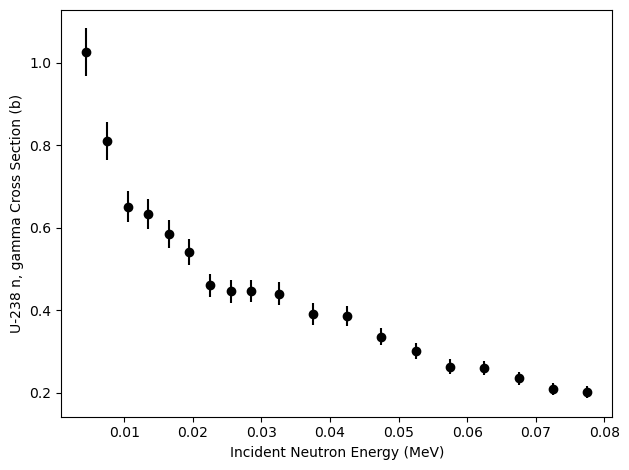

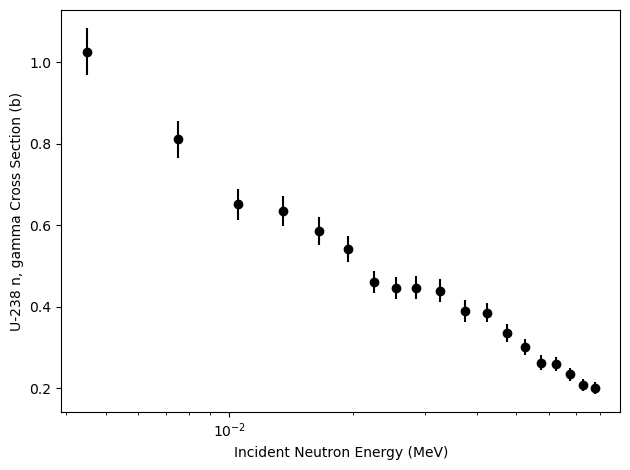

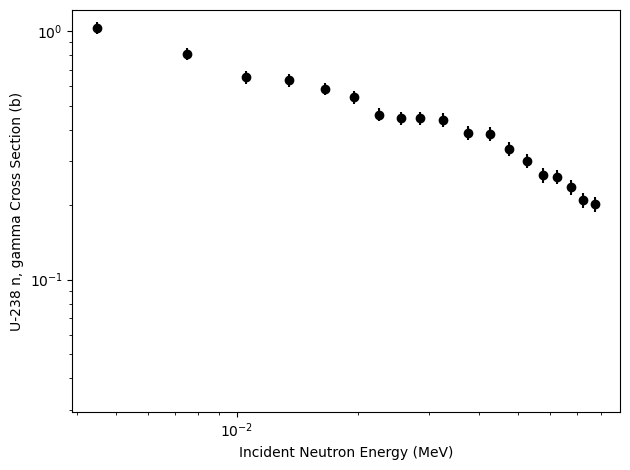

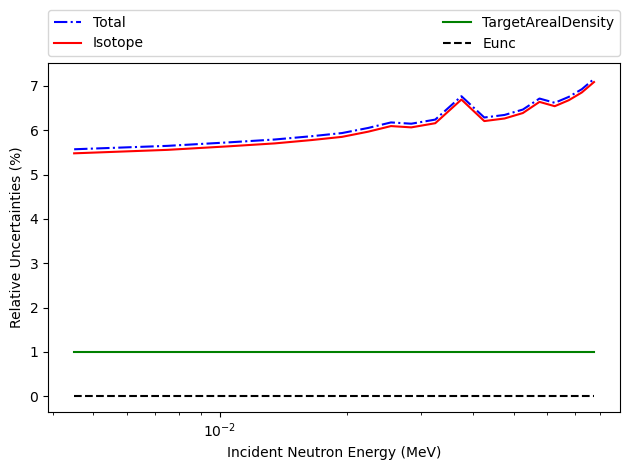

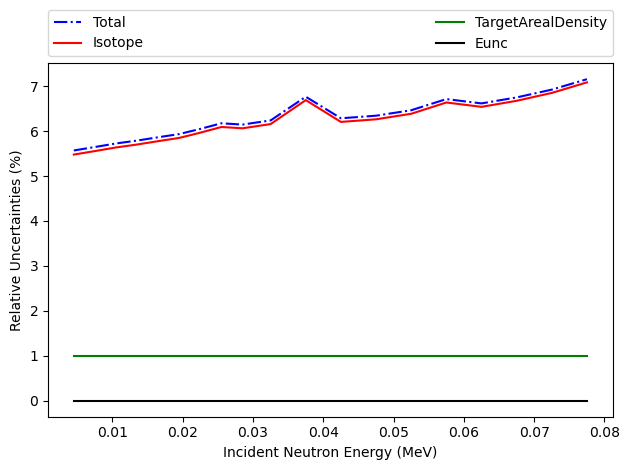

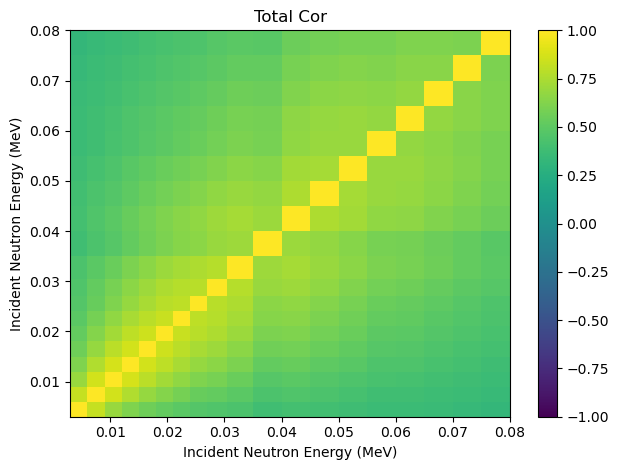

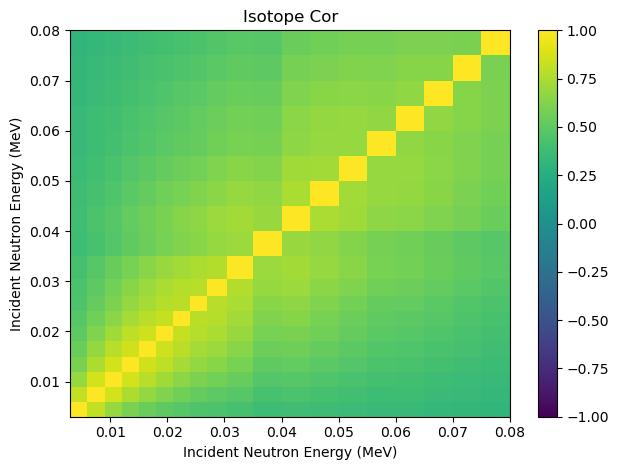

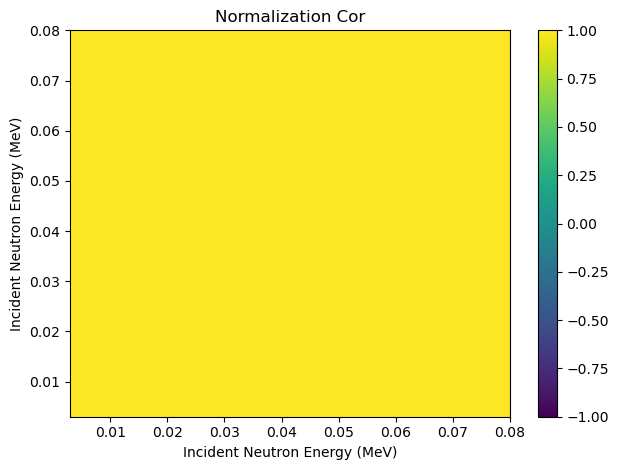

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/MatrixFunctions.py:44: RuntimeWarning: invalid value encountered in scalar divide
  cor[index1,index2] = cov[index1,index2]/\


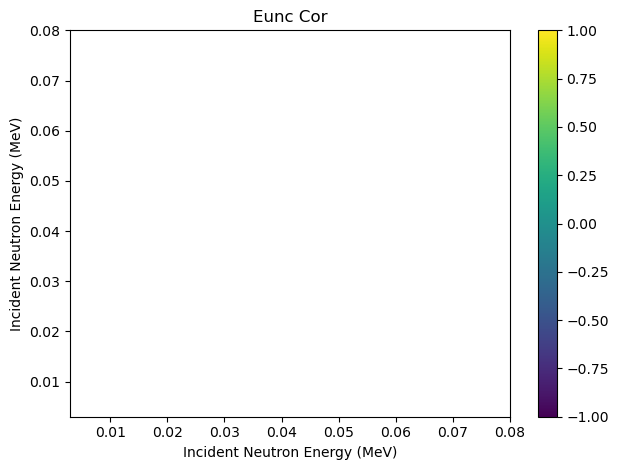

In [35]:
Documentation = """EXFOR No. = 23234004 
Journal article = F.Mingrone et al., PR/C,95,034604,2017.
- 23234004 and 23234005 are from the same raw data, but 23234004 is given with broader energy bins. I take 23234004 as the Standards use averaged data.
- We decided to truncate data due to the second concern above 80 keV. Roberto Capote mentioned background concerns.
- A well-documented data set. I have two areas of concern: The one area of concern is that the neutron flux is evaluated using several reactions as we have previously seen for n_TOF measurements. My second area of concern is the fact that a strong deviation from VIII.1 can be seen from 80 keV to 400 keV. They agree with Ullman data but disageree with Carlson 2009 data. No justification is given in the paper.
- In EXFOR, it is written: "Flux was monitored during measurement by a silicon based neutron beam monitor (SiMoN) relying on 6Li(n,t) reaction." However, the data are only given as 238U(n,g) cs in EXFOR not in ratio to 6Li(n,t) cs. For the Standards, it would be better to have the 238U(n,g)/6Li(n,t) ratios. I wonder if we could get them? ... Reading the journal article, this is the typical n_TOF evaluated neutron flux. There is little hope in getting ratio data. So, I will move forward without it.
- The method used is the "total energy detection technique".
- The sample mass uncertainty of 0.1% is on the low end but realistic for a metal sample.
- There is no impurity uncertainty given but the sample has extremely high purity. Therefore, I set this to 0.
- All uncertainties expected by the templates of expected measurement uncertainties are provided.
- All important effects were corrected as far as I can see.
"""         

general_info = {'name': 'ngcs_Mingrone2017', 'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,g', \
                'output_file' : homedir+'ngcs_Mingrone2017.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

norm_unc = sqrt(normalizationunc*normalizationunc + targetarealnodensityunc*targetarealnodensityunc)

normalization_unc = {'value': norm_unc,\
                     'unit':'%',}

resolution = {
              'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'tof_length':features['NeutronBeam']['TOFLength']['Value'],
              'tof_length_unit':features['NeutronBeam']['TOFLength']['Unit'],
              'tof_length_unc':features['NeutronBeam']['TOFLength']['Unc'],
              'tof_length_unc':features['NeutronBeam']['TOFLength']['Unit_Unc'],
              'energy_resolution': Ersl*Einc/100.0,
              'energy_resolution_unit': 'MeV'
              }

einc_unc = {'en_err' : {'enerr_unc': array(Ersl*0.2/2.355),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.1','resolution':resolution}


unc_iso = {'einc_unc': einc_unc,\
           'normalization_unc': normalization_unc,\
           'values':array([Statunc,backgroundconstunc,fluxnormunc]).transpose(),\
           'units':['%','%','%'],\
           'type':['Diagonal','Gaussian','Gaussian'],\
           'type_arg':{'einc':array(Einc),\
                       'damp_term':[1.0,1.0,1.0],}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }

Mingrone2017 = Cg.ngammacs_absolute(general_info,data,unc_iso,features)

In [37]:
datafile = homedir+'Partial_Unc.dat'
alldata  = loadtxt(datafile)
EincA  = alldata[:,0] # MeV
DataA  = alldata[:,1]
TotuncA = alldata[:,2]

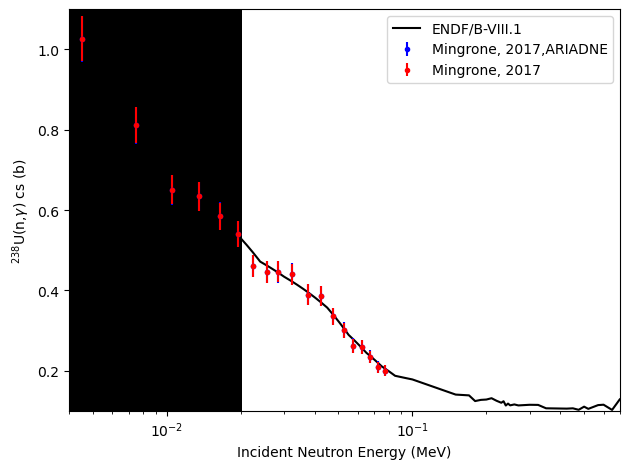

In [39]:
plt.figure(1)
plt.xlim([0.004,0.7])
plt.ylim([0.1,1.1])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel(r'$^{238}$U(n,$\gamma$) cs (b)')
plt.semilogx(EVIII1,csVIII1,'k',zorder=1,label="ENDF/B-VIII.1")
plt.errorbar(EincA,DataA,TotuncA*DataA/100.0,fmt='b.',label="Mingrone, 2017,ARIADNE",zorder=2)
plt.errorbar(Einc,Data,Totunc*Data/100.0,fmt='r.',label="Mingrone, 2017",zorder=2)
plt.legend()
#plt.savefig('/Users/dneudecker/Documents/pu-239-neutron-induced-fission-cross-section/ARIADNE/WorkDir/Ti-48/cs_PlotEXFOR/Ti48_totcs.pdf')

In [59]:
dim = shape(Einc)[0]
GMAnewnumber='6013'
year = features["Year"]
authors = 'Mingrone'
journal = 'J,PR/C,95,034604,2017'
        

normalizationunc2 = [normalizationunc,targetarealnodensityunc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]

uncertainty_descriptor = ['UNCERTAINTIES','1 Normal. unc., sample mass unc. (impurity negligible)',\
                          '1 Energy unc. assumed to be 20% of energy resolution.',\
                          '2 Energy resl explicitly given.',\
                          '3 Statistical Unc.','4 Background Unc.',\
                          '5 Neutron Flux Shape unc.',\
                          'Concern 1: n_TOF neutron flux is evaluated using several reactions.',\
                          'Concern 2: deviates from VIII.1 and Carlson2009 from 80-400 keV, agrees with Ullman2014.',\
                          'Due to concern 2, we truncate data above 80 keV (possible background issue).' ]
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4:6,:] = [0.99,0.01,0.5]
#abc_components[5,:] = [0.0, 1.0,0.01]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:3] = array([Statunc,backgroundconstunc,fluxnormunc]).transpose()

controlnumber = [0,0,9,1,1,0,0,0,0,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = Ersl
Eunc = Ersl*0.2/2.355
abs_shape = 'absolute'
reference = 'none'

[[[[[[[1.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[[[[[[[1.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] 0.1
[[0.99 0.01 0.5 ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.1  0.9  0.01]
 [0.99 0.01 0.5 ]
 [0.99 0.01 0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]] [[0.87364522 3.         4.5        0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [

In [57]:
import WriteGMAOutput as WGMA
print(WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc2))

TypeError: unsupported format string passed to list.__format__